# Selección de atributos: filtros, wrappers y métodos embebidos

> Cómo quedarse con las variables que realmente aportan: eliminar las constantes y redundantes, puntuar cada variable frente a la objetivo (filtros), buscar subconjuntos con el propio modelo (wrappers) o dejar que el modelo las seleccione al entrenar (métodos embebidos). Y cómo medir la importancia de una variable sin engañarse.
>
> **Requisitos previos:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · **Relacionado:** [Reducción de dimensionalidad](02-reduccion-dimensionalidad.ipynb), [Análisis exploratorio](../03-preparacion-datos/01-analisis-exploratorio.ipynb)

## 1. Idea clave

Tener muchas variables no ayuda por sí mismo: las irrelevantes añaden ruido y riesgo de sobreajuste, las redundantes repiten información, y todas aumentan el coste de entrenar, de recoger datos y de interpretar el modelo.

La **selección de atributos** (*feature selection*) busca el subconjunto de variables **originales** que conserva la información útil para predecir. Se diferencia de la [reducción de dimensionalidad](02-reduccion-dimensionalidad.ipynb), que crea variables **nuevas** (combinaciones) y pierde la interpretación directa.

Hay tres familias:

- **Filtros** (*filter*): puntúan cada variable con un criterio estadístico, sin usar el modelo final. Rápidos, pero ciegos a la redundancia y a las interacciones.
- **Wrappers**: prueban subconjuntos de variables entrenando el propio modelo y se quedan con el mejor. Más precisos, más costosos y con más riesgo de sobreajustar la selección.
- **Embebidos** (*embedded*): la selección ocurre durante el entrenamiento (regularización L1, importancia en árboles).

Sea cual sea el método, la selección **aprende de los datos**, así que debe ir **dentro** de la validación cruzada.

## 2. Conceptos importantes

### 2.1. Irrelevancia y redundancia

- Una variable es **irrelevante** si no aporta información sobre la objetivo (por ejemplo, un identificador o ruido).
- Una variable es **redundante** si su información ya está en otras. El caso extremo son dos columnas idénticas o casi (correlación ≈ 1): con una basta. El radio, el perímetro y el área de un círculo, por ejemplo, dicen lo mismo.
- Una variable puede ser **inútil sola y útil en combinación** con otra (interacción). Los métodos que miran las variables de una en una no la detectan.

### 2.2. Filtros

**Sin usar la objetivo:**
- **Varianza**: una variable constante (o casi) no puede discriminar nada.
- **Correlación entre variables**: de cada par con $|r|$ muy alto (por ejemplo, $> 0{,}95$) se descarta una.

**Univariantes frente a la objetivo** (cada variable por separado):

| Criterio | Tipo de relación que detecta | Requisitos |
|---|---|---|
| Correlación (Pearson, Spearman) | Lineal / monótona | Variables numéricas u ordinales |
| **ANOVA F** (`f_classif`) | Diferencia de medias entre clases | Numéricas frente a objetivo categórica |
| **$\chi^2$** (`chi2`) | Dependencia entre frecuencias | Valores **no negativos** (recuentos, binarios) |
| **Información mutua** (`mutual_info_classif`) | **Cualquier** dependencia, también no lineal | Estimación ruidosa con pocos datos |

La **información mutua** entre una variable $X$ y la objetivo $Y$ mide cuánto se reduce la incertidumbre (la entropía) de $Y$ al conocer $X$:

$$
I(X; Y) = H(Y) - H(Y \mid X) \geq 0
$$

donde $H(Y) = -\sum_y p(y)\log p(y)$ es la entropía de $Y$ y $H(Y \mid X)$ la que queda al conocer $X$. Vale 0 si son independientes. Es la misma idea que la **ganancia de información** que usan los [árboles de decisión](08-arboles-decision.ipynb) para elegir cada división.

### 2.3. Wrappers

Evalúan **subconjuntos** entrenando el modelo con validación cruzada:

- **Búsqueda exhaustiva**: probar las $2^p - 1$ combinaciones posibles de $p$ variables. Con 40 variables son más de un billón: solo es viable con muy pocas. Técnicas como *branch and bound* podan la búsqueda, pero sigue siendo cara.
- **Selección paso a paso** (*stepwise*):
  - **hacia delante** (*forward*): empieza sin variables y añade, una a una, la que más mejora el modelo;
  - **hacia atrás** (*backward*): empieza con todas y quita la que menos aporta.
- **Eliminación recursiva** (RFE, *recursive feature elimination*): entrena, quita las variables con menor peso o importancia y repite. `RFECV` elige además el número de variables con validación cruzada.

Como eligen las variables que mejor funcionan **juntas**, tienen en cuenta la redundancia y las interacciones.

### 2.4. Métodos embebidos

- **Regularización L1** (Lasso, regresión logística con `l1_ratio=1`): añade a la función de coste un término proporcional a $\sum_j |\beta_j|$, la suma de los valores absolutos de los coeficientes. Empuja muchos coeficientes **exactamente a cero**, de modo que el modelo selecciona variables mientras aprende. El parámetro de regularización ($C$ en scikit-learn, inverso de la fuerza) controla cuántas sobreviven.
- **Importancia en árboles**: los árboles y los bosques miden cuánto reduce cada variable la impureza en sus divisiones (`feature_importances_`).

### 2.5. Importancia de una variable: impureza frente a permutación

- **Importancia por impureza** (MDI, *mean decrease in impurity*): se calcula con los datos de **entrenamiento** y está **sesgada** hacia variables con muchos valores distintos (continuas, identificadores, categóricas de alta cardinalidad). Hasta el ruido puro recibe algo de importancia.
- **Importancia por permutación**: se barajan al azar los valores de una variable en el conjunto de **prueba** y se mide cuánto empeora el modelo. Si no empeora, el modelo no la usa de verdad. Su limitación: si dos variables están correlacionadas, al barajar una el modelo sigue teniendo la otra, y ambas parecen poco importantes.

## 3. Código

Usamos **breast_cancer** de scikit-learn (569 tumores, 30 medidas de imágenes de células; procede del conjunto *Breast Cancer Wisconsin (Diagnostic)* del repositorio UCI), con maligno = 1. Muchas de sus variables son redundantes: para cada núcleo celular se mide el radio, el perímetro y el área, y cada medida aparece tres veces (media, error típico y "peor" valor). Para comprobar si los métodos distinguen lo útil de lo inútil, añadimos **10 variables de ruido** aleatorio y **1 constante**.

### 3.1. Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (
    RFECV, SelectKBest, SequentialFeatureSelector, VarianceThreshold,
    f_classif, mutual_info_classif,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_original = load_breast_cancer(return_X_y=True, as_frame=True)
y = 1 - y_original  # 1 = maligno

rng = np.random.default_rng(42)
for i in range(10):
    X[f"ruido_{i}"] = rng.normal(size=len(X))
X["constante"] = 1.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
es_ruido = X.columns.str.startswith("ruido")
print(X_train.shape)

(426, 41)


### 3.2. Filtros sin la objetivo: varianza y redundancia

In [3]:
varianza = VarianceThreshold(threshold=0.0).fit(X_train)
print(f"Variables con varianza 0: {list(X_train.columns[~varianza.get_support()])}")

# Pares de variables muy correlacionadas (triángulo superior de la matriz)
corr = X_train.drop(columns="constante").corr().abs()
superior = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pares = superior.stack().sort_values(ascending=False)
print(f"Pares con |r| > 0,95: {(pares > 0.95).sum()}")
pares.head(5).round(3).to_frame("|r|")

Variables con varianza 0: ['constante']
Pares con |r| > 0,95: 15


,,|r|
mean radius,mean perimeter,0.998
worst radius,worst perimeter,0.994
mean radius,mean area,0.986
mean perimeter,mean area,0.986
worst radius,worst area,0.983


El radio medio y el perímetro medio tienen una correlación de 0,998: en la práctica son la misma variable. Hay 15 pares por encima de 0,95. Un modelo lineal con todas reparte los coeficientes entre ellas de forma inestable, y cualquier medida de importancia se diluye.

### 3.3. Filtros univariantes frente a la objetivo

Puntuamos cada variable con ANOVA F y con información mutua:

In [4]:
X_sin_constante = X_train.drop(columns="constante")
puntuaciones = pd.DataFrame({
    "ANOVA F": SelectKBest(f_classif, k="all").fit(X_sin_constante, y_train).scores_,
    "información mutua": mutual_info_classif(X_sin_constante, y_train, random_state=42),
}, index=X_sin_constante.columns)

print("Las 6 mejores según ANOVA F:")
print(puntuaciones.sort_values("ANOVA F", ascending=False).head(6).round(3))

rango = puntuaciones.rank(ascending=False)
print(f"\nMejor posición de una variable de ruido: ANOVA F {int(rango.loc[es_ruido[:-1], 'ANOVA F'].min())}, "
      f"información mutua {int(rango.loc[es_ruido[:-1], 'información mutua'].min())} (de 40)")

Las 6 mejores según ANOVA F:
                      ANOVA F  información mutua
worst concave points  659.600              0.421
worst perimeter       655.555              0.454
worst radius          636.017              0.461
mean concave points   618.003              0.443
mean perimeter        504.143              0.405
worst area            477.821              0.451

Mejor posición de una variable de ruido: ANOVA F 26, información mutua 28 (de 40)


- Ambos criterios colocan el ruido lejos de las primeras posiciones: los filtros detectan bien lo **irrelevante**.
- Pero las primeras posiciones están ocupadas por variables de **tamaño** (radio, perímetro, área) y de **concavidad**, en sus versiones media y "peor", muy correlacionadas entre sí: el peor radio y el peor perímetro, por ejemplo, tienen una correlación de 0,994. Un filtro univariante no ve la **redundancia**: si nos quedamos con las $k$ mejores, gran parte serán copias de la misma información.

Comprobamos el efecto con validación cruzada, con el filtro dentro del `Pipeline`:

In [5]:
def exactitud(modelo, X_):
    return cross_val_score(modelo, X_, y_train, cv=cv).mean()

logistica = lambda **kw: LogisticRegression(max_iter=5000, **kw)

resultados = {"Todas las variables (41)": exactitud(make_pipeline(StandardScaler(), logistica()), X_train)}
for k in [5, 10]:
    resultados[f"Filtro ANOVA F, {k} mejores"] = exactitud(
        make_pipeline(VarianceThreshold(), StandardScaler(), SelectKBest(f_classif, k=k), logistica()), X_train)
pd.Series(resultados, name="exactitud (CV)").round(3).to_frame()

,exactitud (CV)
Todas las variables (41),0.962
"Filtro ANOVA F, 5 mejores",0.944
"Filtro ANOVA F, 10 mejores",0.944


Quedarse con las 5 o 10 mejores según el filtro **empeora** el modelo respecto a usar todas: esas variables repiten casi la misma información y se pierden otras que aportan algo distinto (la textura, la suavidad del contorno…).

### 3.4. Wrappers: selección paso a paso y eliminación recursiva

La **selección hacia delante** añade en cada paso la variable que más mejora la validación cruzada del modelo:

In [6]:
sfs = SequentialFeatureSelector(
    make_pipeline(StandardScaler(), logistica()), n_features_to_select=5,
    direction="forward", cv=cv)
sfs.fit(X_train, y_train)

elegidas_sfs = X_train.columns[sfs.get_support()]
print(f"Variables elegidas: {list(elegidas_sfs)}")
resultados["Selección hacia delante, 5 variables"] = exactitud(
    make_pipeline(StandardScaler(), logistica()), X_train[elegidas_sfs])
print(f"Exactitud (CV) con esas 5: {resultados['Selección hacia delante, 5 variables']:.3f}")

Variables elegidas: ['mean radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness']
Exactitud (CV) con esas 5: 0.974


Con solo 5 variables, el wrapper **supera** al modelo con todas. Elige variables **complementarias**: tamaño, textura y forma del contorno, en lugar de cinco versiones del tamaño.

`RFECV` elimina variables de una en una según los coeficientes del modelo, y elige el número con validación cruzada:

Número de variables elegido: 17
Variables de ruido entre las elegidas: 0


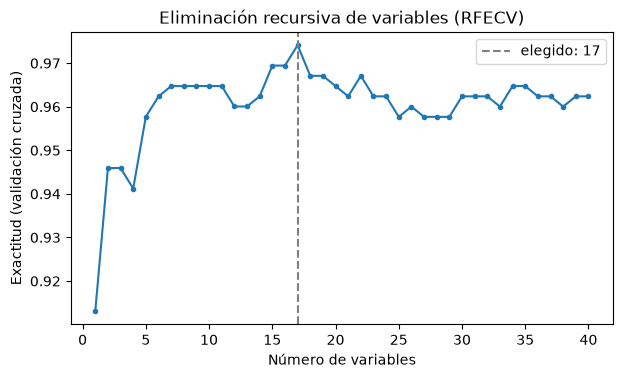

In [7]:
rfecv = RFECV(make_pipeline(StandardScaler(), logistica()), cv=cv,
              importance_getter="named_steps.logisticregression.coef_")
rfecv.fit(X_train.drop(columns="constante"), y_train)

print(f"Número de variables elegido: {rfecv.n_features_}")
print(f"Variables de ruido entre las elegidas: {rfecv.support_[es_ruido[:-1]].sum()}")

n_variables = np.arange(1, len(rfecv.cv_results_["mean_test_score"]) + 1)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(n_variables, rfecv.cv_results_["mean_test_score"], marker=".")
ax.axvline(rfecv.n_features_, color="gray", linestyle="--", label=f"elegido: {rfecv.n_features_}")
ax.set_xlabel("Número de variables")
ax.set_ylabel("Exactitud (validación cruzada)")
ax.set_title("Eliminación recursiva de variables (RFECV)")
ax.legend()
plt.show()

La curva sube deprisa con las primeras variables y después forma una meseta en torno a 0,96, que ya se alcanza con unas 7. El máximo (17 variables) apenas la supera y podría deberse al azar de las particiones: con un resultado así, un subconjunto más pequeño es igual de defendible. Ninguna variable de ruido entra en la selección.

### 3.5. Métodos embebidos: regularización L1

Con `l1_ratio=1` (penalización L1 pura), la regresión logística pone a cero los coeficientes de las variables que no necesita:

In [8]:
l1 = make_pipeline(StandardScaler(), logistica(l1_ratio=1, solver="liblinear", C=0.1))
l1.fit(X_train.drop(columns="constante"), y_train)
coef = pd.Series(l1[-1].coef_[0], index=X_train.columns.drop("constante"))

print(f"Coeficientes distintos de cero: {(coef != 0).sum()} de {len(coef)} (ruido: {(coef[es_ruido[:-1]] != 0).sum()})")
resultados["Regresión logística L1 (C=0,1)"] = exactitud(l1, X_train.drop(columns="constante"))
print(coef[coef != 0].sort_values(key=abs, ascending=False).round(3))

Coeficientes distintos de cero: 7 de 40 (ruido: 0)
worst radius            2.071
mean concave points     0.980
worst texture           0.668
worst concave points    0.410
radius error            0.303
worst symmetry          0.224
worst smoothness        0.172
dtype: float64


Con $C = 0{,}1$ sobreviven unas pocas variables, ninguna de ruido. Entre las variables de tamaño muy correlacionadas, L1 suele quedarse con una o dos y anular el resto. Qué variable concreta elige dentro de un grupo redundante es bastante arbitrario, así que no hay que sobreinterpretarlo.

### 3.6. Importancia por impureza frente a permutación

Entrenamos un *random forest* y comparamos sus dos medidas de importancia. La de permutación se calcula en el conjunto de **prueba**:

Importancia total asignada al ruido — impureza: 0.027 | permutación: -0.016


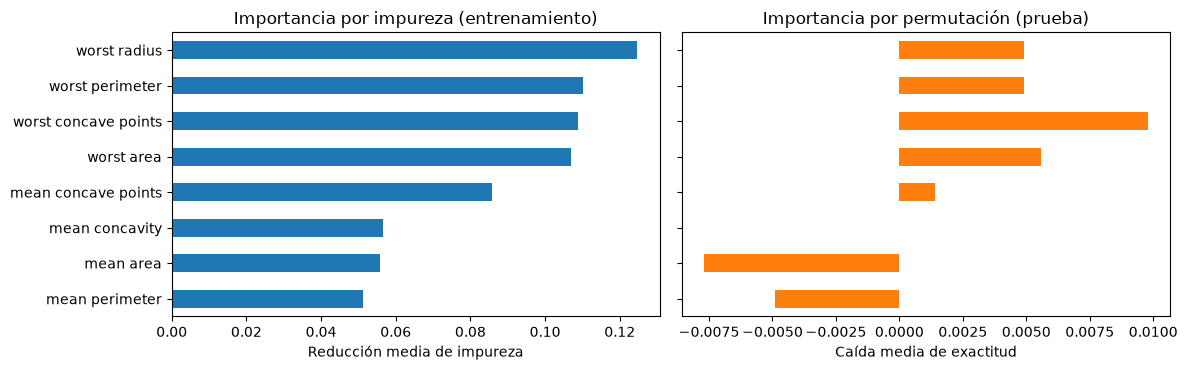

In [9]:
bosque = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)
impureza = pd.Series(bosque.feature_importances_, index=X_train.columns)
permutacion = pd.Series(
    permutation_importance(bosque, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1).importances_mean,
    index=X_train.columns)

print(f"Importancia total asignada al ruido — impureza: {impureza[es_ruido].sum():.3f} | "
      f"permutación: {permutacion[es_ruido].sum():.3f}")

top = impureza.sort_values(ascending=False).head(8).index
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
impureza[top].iloc[::-1].plot.barh(ax=axes[0], color="tab:blue")
axes[0].set_title("Importancia por impureza (entrenamiento)")
axes[0].set_xlabel("Reducción media de impureza")
permutacion[top].iloc[::-1].plot.barh(ax=axes[1], color="tab:orange")
axes[1].set_title("Importancia por permutación (prueba)")
axes[1].set_xlabel("Caída media de exactitud")
plt.tight_layout()
plt.show()

- La **impureza** reparte algo de importancia entre las 10 variables de ruido (un 2,7 % en total): el bosque las usa en divisiones que solo sirven para el entrenamiento. Por **permutación** su importancia total es prácticamente nula, incluso ligeramente negativa (−0,016): barajarlas no empeora las predicciones en prueba, y las pequeñas variaciones se deben al azar.
- Las variables de tamaño son las más importantes por impureza, pero por permutación parecen poco importantes (el área media y el perímetro medio salen incluso negativas): al barajar el "peor radio", el bosque sigue teniendo el "peor perímetro" y el "peor área", que dicen lo mismo. Con variables correlacionadas, la importancia por permutación de cada una **subestima** la del grupo.

### 3.7. Resumen de la comparación

In [10]:
pd.Series(resultados, name="exactitud (CV)").round(3).to_frame()

,exactitud (CV)
Todas las variables (41),0.962
"Filtro ANOVA F, 5 mejores",0.944
"Filtro ANOVA F, 10 mejores",0.944
"Selección hacia delante, 5 variables",0.974
"Regresión logística L1 (C=0,1)",0.972


## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase / función | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `VarianceThreshold` | `threshold` | Varianza mínima para conservar una variable | `0` elimina solo las constantes; con variables binarias, $p(1-p)$ |
| `SelectKBest` / `SelectPercentile` | `score_func`, `k` / `percentile` | Criterio y cuántas variables se quedan | `f_classif`, `chi2` (≥ 0), `mutual_info_classif`; elige `k` con validación cruzada |
| `mutual_info_classif` | `n_neighbors`, `random_state` | Estimación de la información mutua | Estimación ruidosa: fija la semilla y no sobreinterpretes diferencias pequeñas |
| `SequentialFeatureSelector` | `direction`, `n_features_to_select`, `cv` | Hacia delante o hacia atrás; cuántas | Coste ≈ nº de variables × nº de pasos × nº de particiones |
| `RFE` / `RFECV` | `step`, `min_features_to_select`, `importance_getter` | Cuántas se quitan por iteración; de dónde sale la importancia | En un `Pipeline`, indica la ruta al estimador (`named_steps.<paso>.coef_`) |
| `SelectFromModel` | `estimator`, `threshold`, `max_features` | Selección a partir de coeficientes o importancias | Con L1 o con árboles |
| `LogisticRegression` | `l1_ratio`, `C`, `solver` | Tipo de regularización (1 = L1, 0 = L2) y su fuerza | `solver="liblinear"` o `"saga"`; `C` pequeño → menos variables. En versiones anteriores a scikit-learn 1.8 se usaba `penalty="l1"` |
| `permutation_importance` | `n_repeats`, `scoring` | Repeticiones y métrica | Calcúlala en datos de prueba o validación, no en entrenamiento |

### 4.2. Errores comunes

Varias de estas lecciones salen de trabajo real: un clasificador de *malware* con decenas de variables de sistema, un clasificador de éxito comercial de videojuegos y un clasificador del estado de turbinas eólicas a partir de sensores.

**1. Seleccionar variables antes de la validación cruzada.** Es el error más grave y el más fácil de cometer: se eligen las variables "más correlacionadas con la objetivo" con todos los datos y después se valida el modelo. Con datos de **puro ruido** (100 observaciones, 5.000 variables aleatorias y una etiqueta al azar), el resultado es espectacular y completamente falso:

In [11]:
X_ruido = rng.normal(size=(100, 5000))
y_ruido = rng.integers(0, 2, size=100)

# MAL: elegir las 20 variables más correlacionadas con y usando TODOS los datos
corr_con_y = np.abs([np.corrcoef(X_ruido[:, j], y_ruido)[0, 1] for j in range(X_ruido.shape[1])])
top20 = np.argsort(corr_con_y)[::-1][:20]
mal = cross_val_score(logistica(), X_ruido[:, top20], y_ruido, cv=cv).mean()

# BIEN: la selección dentro del Pipeline, repetida en cada partición
bien = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), logistica()), X_ruido, y_ruido, cv=cv).mean()

print(f"Selección fuera de la validación cruzada: {mal:.2f}")
print(f"Selección dentro del Pipeline:            {bien:.2f}  (la real, cercana al 50 % del azar)")

Selección fuera de la validación cruzada: 0.90
Selección dentro del Pipeline:            0.45  (la real, cercana al 50 % del azar)


Entre 5.000 variables aleatorias, siempre hay algunas que, por casualidad, se correlacionan con la etiqueta en **estos** 100 datos. Si se eligen mirando también las particiones de validación, la validación cruzada solo confirma esa casualidad. Dentro del `Pipeline`, la selección se repite en cada partición solo con su entrenamiento, y el resultado vuelve al azar.

**2. Conservar variables duplicadas.** En los datos de turbinas había dos columnas de vibración del eje, una de ellas marcada como redundante, con correlación **1,000** entre ambas, y se mantuvieron las dos en el modelo. Una copia exacta no aporta información. Además, en modelos lineales reparte el coeficiente de forma arbitraria entre las dos, y en la importancia por permutación hace que ninguna parezca importante (3.6). Revisa la matriz de correlaciones antes de modelar (3.2).

**3. Fiarse solo de filtros univariantes.** En el clasificador de *malware* se eligieron las 4 variables más correlacionadas (Spearman) con la objetivo, y en un gráfico por pares sus clases seguían muy solapadas. Un filtro univariante mide cada variable por separado: no ve que varias dicen lo mismo (3.3) ni que otras solo son útiles en combinación. Úsalo para descartar lo claramente irrelevante, y para lo demás usa wrappers, métodos embebidos o, sobre todo, el rendimiento del modelo en validación cruzada.

**4. Interpretar `feature_importances_` como la verdad.** En el clasificador de videojuegos, las dos únicas variables numéricas (número de valoraciones y año) acapararon el **75 %** de la importancia por impureza del árbol, frente a miles de columnas binarias de desarrollador y editor. La importancia por impureza favorece a las variables continuas y se calcula con el entrenamiento, así que incluso el ruido recibe una parte (3.6). Contrástala con la importancia por **permutación** en datos de prueba.

**5. Codificar categóricas de alta cardinalidad sin agrupar y seleccionar después.** En ese mismo problema, 7 columnas originales se convirtieron en unas **3.900** tras el one-hot (2.596 desarrolladores y 1.182 editores distintos), para unos 9.000 videojuegos. La mayoría de esas columnas tienen solo uno o dos unos. Antes de pedirle a un método de selección que encuentre la aguja en ese pajar, conviene agrupar las categorías raras o usar otra codificación (ver [transformación de datos](../03-preparacion-datos/03-transformacion-datos.ipynb)).

**6. Aplicar $\chi^2$ a variables con valores negativos.** `chi2` solo es válido con valores no negativos (recuentos, frecuencias, binarias). Con variables estandarizadas da error, y con otras transformaciones da resultados sin sentido.

## 5. Comparación con métodos relacionados

| Método | Familia | Usa el modelo | Ve redundancia | Ve interacciones | Coste | Cuándo usarlo |
|---|---|---|---|---|---|---|
| Varianza / correlación entre variables | Filtro sin objetivo | No | Sí (por pares) | No | Muy bajo | Siempre, como limpieza inicial |
| ANOVA F, $\chi^2$, correlación con la objetivo | Filtro univariante | No | No | No | Muy bajo | Muchísimas variables; descartar lo irrelevante |
| Información mutua | Filtro univariante | No | No | No (sí dependencias no lineales) | Bajo | Relaciones no lineales con la objetivo |
| Búsqueda exhaustiva | Wrapper | Sí | Sí | Sí | Intratable salvo pocas variables | Casi nunca |
| Selección paso a paso | Wrapper | Sí | Sí | Parcialmente | Alto | Pocas decenas de variables; modelos rápidos |
| RFE / RFECV | Wrapper (con pesos del modelo) | Sí | Parcialmente | Parcialmente | Medio | Modelos con coeficientes o importancias |
| Regularización L1 | Embebido | Sí | Parcialmente (elige una de cada grupo, al azar) | No | Bajo | Modelos lineales con muchas variables |
| Importancia en árboles + `SelectFromModel` | Embebido | Sí | No (reparte) | Sí | Bajo | Modelos de árboles; contrastar con permutación |
| Reducción de dimensionalidad (PCA…) | Extracción | No | Sí (combina) | No | Bajo | Cuando no hace falta conservar las variables originales |

## 6. Referencias

### Fuentes

- scikit-learn: [*Feature selection*](https://scikit-learn.org/stable/modules/feature_selection.html) (filtros, `RFECV`, `SelectFromModel`, `SequentialFeatureSelector`) y [*Permutation feature importance*](https://scikit-learn.org/stable/modules/permutation_importance.html).
- Dataset: [breast_cancer en scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html), procedente del conjunto *Breast Cancer Wisconsin (Diagnostic)* del repositorio UCI.

### Para saber más

- Guyon, I. y Elisseeff, A. (2003). *An Introduction to Variable and Feature Selection*. Journal of Machine Learning Research, 3, 1157–1182. La introducción de referencia: filtros, wrappers, métodos embebidos y errores habituales.
- Kohavi, R. y John, G. H. (1997). *Wrappers for Feature Subset Selection*. Artificial Intelligence, 97(1–2), 273–324. El artículo que define y analiza el enfoque wrapper.